# Intro to Quantitative Finance

In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import requests
from scipy.stats import norm
from scipy.optimize import minimize
import asyncio
from api import *

### Calculating the Beta of a Stock

In [6]:
stock = 'NVDA'

sx = requests.get(historical('SPY')).json()
sp = pd.DataFrame(sx)[::-1]
await asyncio.sleep(3)

sy = requests.get(historical(stock)).json()
sr = pd.DataFrame(sy)[::-1]

print(sr.head())

     symbol        date  price     volume
1254   NVDA  2021-03-03  12.80  377592000
1253   NVDA  2021-03-04  12.37  573345160
1252   NVDA  2021-03-05  12.46  542840000
1251   NVDA  2021-03-08  11.59  543112000
1250   NVDA  2021-03-09  12.52  521825520


In [9]:
price_x = sp['price'].values
price_y = sr['price'].values

rX = price_x[1:] / price_x[:-1] - 1.0
rY = price_y[1:] / price_y[:-1] - 1.0

X = np.vstack([np.ones(len(rX)), rX]).T
y = rY

beta = np.linalg.inv(X.T.dot(X)).dot(X.T.dot(y))
print(beta)

[1.52773750e-03 2.13437176e+00]


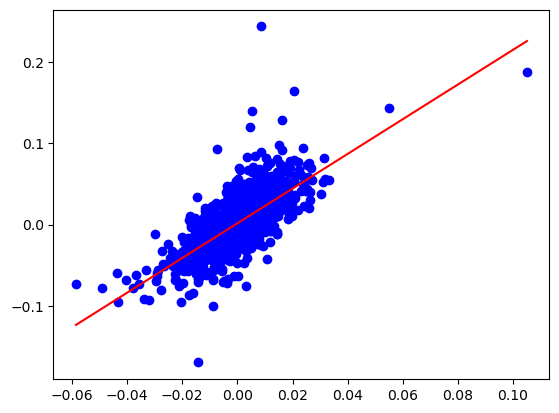

In [10]:
r0 = np.min(rX)
r1 = np.max(rX)
nr = 100
rspace = np.linspace(r0, r1, nr)
raxis = np.vstack([np.ones(nr), rspace]).T
yhat = raxis @ beta

fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(rX, rY, color='blue')
ax.plot(rspace, yhat, color='red')
plt.show()

### Black Scholes Model

##### Call Option Equation
$ C = Se^{-q*t}N(d1) - Ke^{-r*t}N(d2) $

##### Put Option Equation
$ P = Ke^{-r*t}N(-d2) - Se^{-q*t}N(-d1)$

$ d1 = \dfrac{ln(S/K) + (r - q + 0.5*\sigma^2)*t}{\sigma \sqrt{t}} $
$ d2 = d1 - \sigma \sqrt{t} $

In [11]:
S = 100
K = 105
rf = 0.05
dv = 0.01
v = 0.15
t = 3

d1 = (np.log(S/K) + (rf - dv + 0.5*v**2)*t)/(v*np.sqrt(t))
d2 = d1 - v*np.sqrt(t)

C = S*np.exp(-dv*t)*norm.cdf(d1) - K*np.exp(-rf*t)*norm.cdf(d2)
P = K*np.exp(-rf*t)*norm.cdf(-d2) - S*np.exp(-dv*t)*norm.cdf(-d1)

print("Call Option Price: ", C)
print("Put Option Price: ", P)



Call Option Price:  13.380007153047977
Put Option Price:  6.709791322828231


### Min-Variance Portfolio

In [13]:
stocks = ['AAPL','MSFT','NFLX','TSLA','SPY']
sess = requests.Session()
hold = []
for stock in stocks:
    resp = sess.get(historical(stock)).json()
    df = pd.DataFrame(resp)
    prices = df['price'][::-1].values.tolist()
    hold.append(prices)
    await asyncio.sleep(2)
    print(stock, ' has loaded')

portfolio = np.array(hold, dtype=float).T

print(portfolio)



AAPL  has loaded
MSFT  has loaded
NFLX  has loaded
TSLA  has loaded
SPY  has loaded
[[122.06 227.56  52.07 217.73 381.42]
 [120.13 226.73  51.13 207.15 376.7 ]
 [121.42 231.6   51.64 199.32 383.63]
 ...
 [272.95 401.72  84.59 408.58 689.3 ]
 [264.18 392.74  96.24 402.51 685.99]
 [264.72 398.55  97.09 403.32 686.38]]


In [15]:
returns = portfolio[1:]/portfolio[:-1] - 1.0

mu = np.mean(returns, axis=0)
cov = np.cov(returns.T)


##### Min-Variance Portfolio Equation

$ \begin{bmatrix} 2 \Sigma & 1 \\ 1 & 0 \end{bmatrix}^{-1} \begin{bmatrix} 0 \\ 1 \end{bmatrix} = \begin{bmatrix} w \\ 1 \end{bmatrix} $ 
<br/>
<br/>
$ L(w, \lambda_1) = w^T \Sigma w + \lambda_1(w1 - 1) $

In [17]:
A = (2.0*cov).tolist()
n = len(A)
for i in range(n):
    A[i].append(1.0)
A.append(np.ones(n).tolist() + [0])
b = np.zeros(n).tolist() + [1.0]
A, b = np.array(A), np.array(b)

min_var_weights = np.linalg.inv(A).dot(b)
min_var_weights = min_var_weights[:-1]

min_var_risk = min_var_weights.T @ cov @ min_var_weights
min_var_risk = np.sqrt(min_var_risk)

print("Portfolio's Min-Variance Risk: ", min_var_risk)

Portfolio's Min-Variance Risk:  0.009946284471430046


#### Black-Scholes Implied Volatility Calculation

In [24]:
def Vega(S, K, rf, dv, v, t):
    d1 = (np.log(S/K) + (rf - dv + 0.5*v**2)*t)/(v*np.sqrt(t))
    return S*norm.cdf(d1)*np.sqrt(t)

def CBS(S, K, rf, dv, v, t):
    d1 = (np.log(S/K) + (rf - dv + 0.5*v**2)*t)/(v*np.sqrt(t))
    d2 = d1 - v*np.sqrt(t)

    return S*np.exp(-dv*t)*norm.cdf(d1) - K*np.exp(-rf*t)*norm.cdf(d2)

In [27]:
# Newton-Ralphsons Method

S = 100
K = 105
rf = 0.05
dv = 0.01
t = 3
option_price = 16.50

v0, v1 = 0.1, 1.0
while True:
    sim_price = CBS(S, K, rf, dv, v0, t)
    sim_vega = Vega(S, K, rf, dv, v0, t)
    v1 = v0 - (sim_price - option_price) / sim_vega
    if abs(v1 - v0) < 0.0001:
        break
    v0 = v1 

print("Implied Volatility: ", v1)
print("Check Price: ", CBS(S, K, rf, dv, v1, t))


Implied Volatility:  0.20009259274255922
Check Price:  16.49531382793412


### Heston Model

##### Stock-Price Function
$ S_t = \mu_t S_{t-1} dt + \sigma_t S_{t-1} dW_t $ 
<br/>
$ v_t = \kappa_t (\theta - v_{t-1}) dt + \epsilon \sqrt{v_{t-1}} dW_s $

In [ ]:
import ctypes

def HParams(ror, t, window=20):
    dt = t / 1000
    hold = []
    for i in range(window, len(ror)):
        data = ror[i-window:i]
        hold.append(np.var(data))
    v0, v1 = hold[:-1], hold[1:]
    cv = np.cov(v0, v1)
    bt = cv[0, 1]/cv[0, 0]
    kappa = -np.log(bt)/dt
    theta = np.mean(hold)
    epsilon = np.std(hold)
    return kappa, theta, epsilon 

In [ ]:
qs = ctypes.CDLL("./quant.so")
qs.HestonModel.argtypes = [ctypes.c_double for u in range(7)]
qs.HestonModel.restype = ctypes.c_double

S = price_y[-1]
mu = np.mean(rX)
vol = np.var(rX)

t = 3.0 / 252.0

[ 12.8   12.37  12.46 ... 184.89 177.19 182.48]
